<a href="https://colab.research.google.com/github/davirodrigues2026/Fonte-de-informa-o-e-Banco-de-dados/blob/main/Consumo_Cerveja_15_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongeorge/beer-consumption-sao-paulo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'beer-consumption-sao-paulo' dataset.
Path to dataset files: /kaggle/input/beer-consumption-sao-paulo


In [9]:
import pandas as pd

display(df.head())

,data,temperatura_media_c,temperatura_minima_c,temperatura_maxima_c,precipitacao_mm,final_de_semana,consumo_de_cerveja_litros
0,2015-01-01,27.30,"23,9","32,5",0,0.0,25.461
1,2015-01-02,27.02,"24,5","33,5",0,0.0,28.972
2,2015-01-03,24.82,"22,4","29,9",0,1.0,30.814
3,2015-01-04,23.98,"21,5","28,6","1,2",1.0,29.799
4,2015-01-05,23.82,21,"28,3",0,0.0,28.900


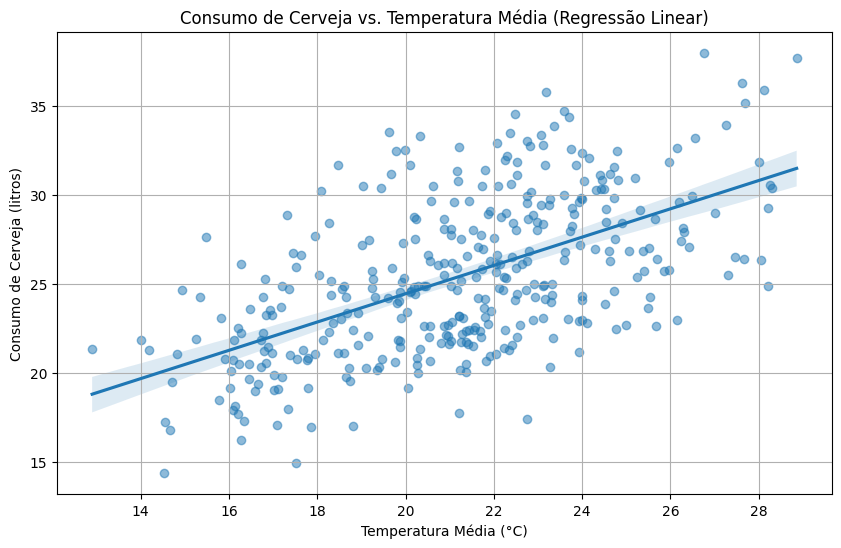

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Rename columns to be more Python-friendly and avoid issues with special characters
# Using regex=False for simple replacements to avoid warnings.
df.columns = df.columns.str.strip().str.replace(' ', '_', regex=False).str.replace('(', '', regex=False).str.replace(')', '', regex=False).str.replace('ã', 'a', regex=False).str.replace('ç', 'c', regex=False).str.lower()

temperature_col = 'temperatura_media_c'
consumption_col = 'consumo_de_cerveja_litros'

# Ensure columns exist before processing
if temperature_col in df.columns and consumption_col in df.columns:
    # Convert 'temperatura_media_c' to numeric, handling potential comma decimals
    if pd.api.types.is_object_dtype(df[temperature_col]):
        df[temperature_col] = df[temperature_col].str.replace(',', '.', regex=False).astype(float)
    elif not pd.api.types.is_numeric_dtype(df[temperature_col]):
        df[temperature_col] = df[temperature_col].astype(float)


    # Convert 'consumo_de_cerveja_litros' to numeric
    if pd.api.types.is_object_dtype(df[consumption_col]):
        df[consumption_col] = df[consumption_col].str.replace(',', '.', regex=False).astype(float)
    elif not pd.api.types.is_numeric_dtype(df[consumption_col]):
        df[consumption_col] = df[consumption_col].astype(float)

    plt.figure(figsize=(10, 6))
    sns.regplot(x=temperature_col, y=consumption_col, data=df, scatter_kws={'alpha':0.5})
    plt.title('Consumo de Cerveja vs. Temperatura Média (Regressão Linear)')
    plt.xlabel('Temperatura Média (°C)')
    plt.ylabel('Consumo de Cerveja (litros)')
    plt.grid(True)
    plt.show()
else:
    print(f"Warning: Required columns '{temperature_col}' or '{consumption_col}' not found. Please check data and column names.")
    print("Available columns:", df.columns.tolist())



Now, let's create the scatter plot. I'll need to identify the correct column names for average temperature and beer consumption from the DataFrame.